## Cruce completo de 2013 a 2023 de todos los tipos de violencia con divorcios

Cargando datos del panel...
Gráfico de cuadrícula generado: dispersion_tipos_vif_vs_divorcios.png


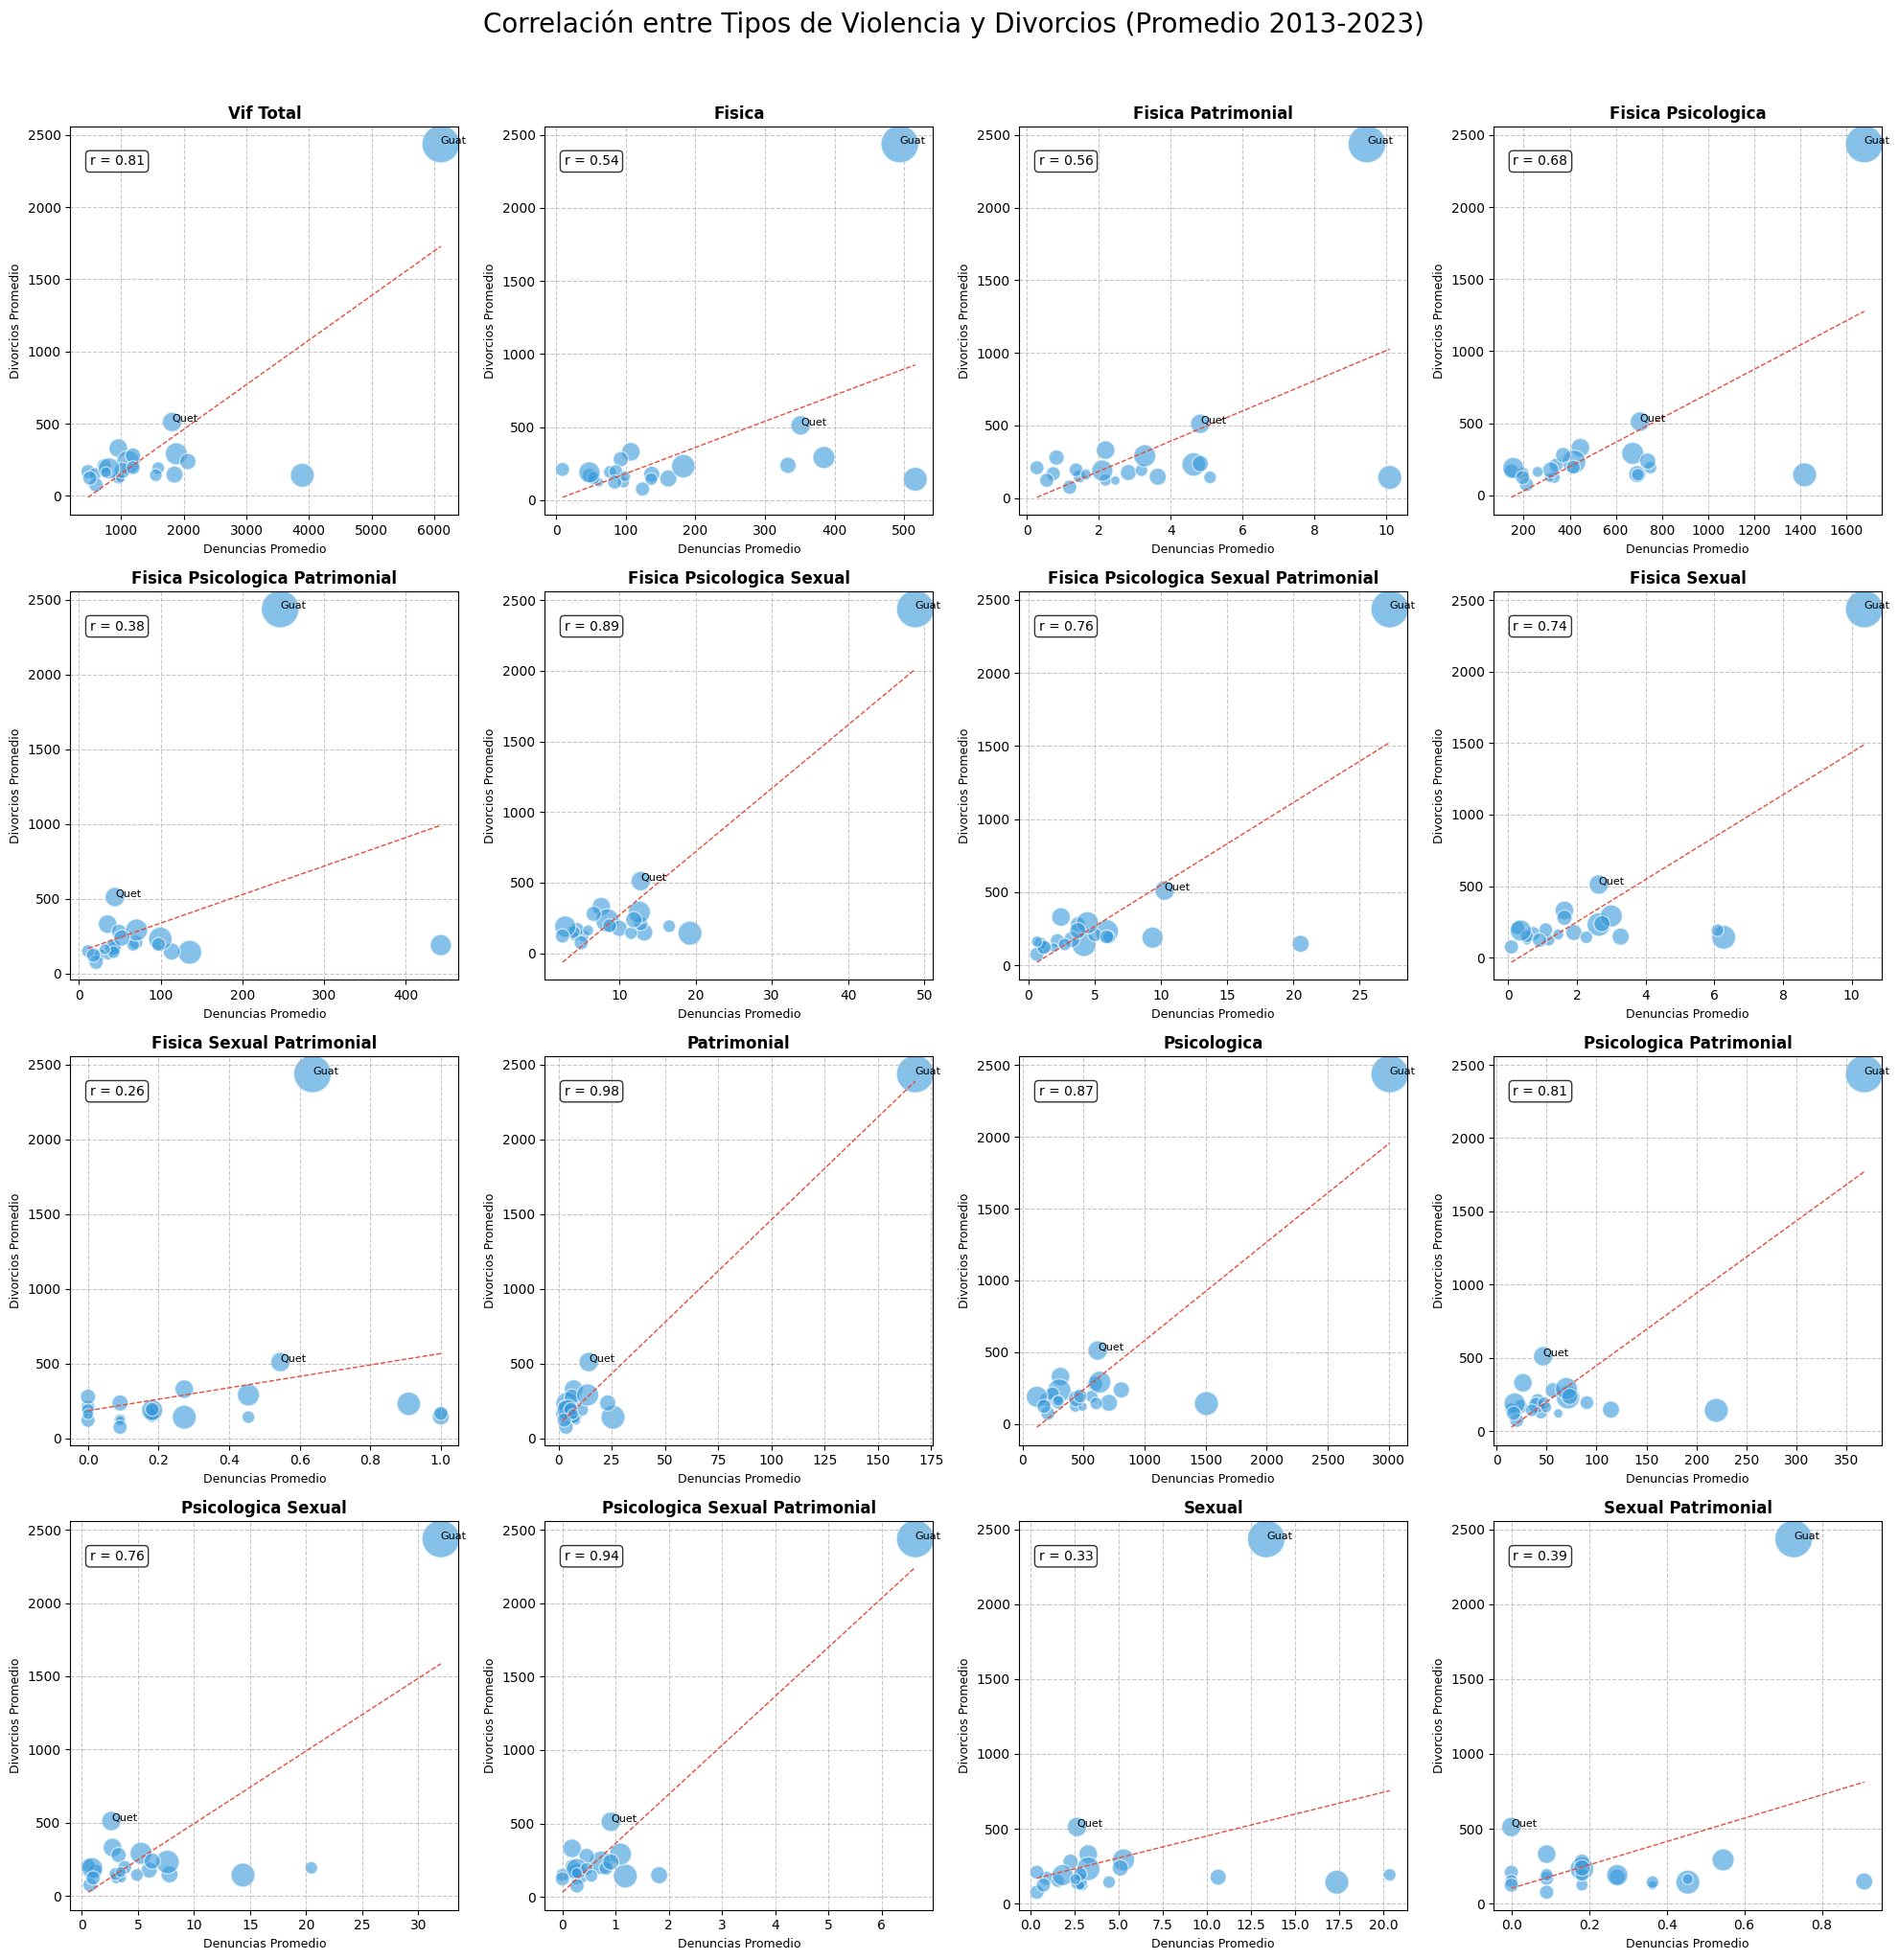

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import math
import numpy as np

# Configurar path para importar data_pipeline
# Intentamos importar, si falla asumimos que estamos en subdir y agregamos padre al path
try:
    import data_pipeline as dp
except ImportError:
    PROJECT_ROOT = Path.cwd().parent
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))
    import data_pipeline as dp

def generar_dispersion_por_tipo_vif():
    # 1. Cargar datos del panel completo
    print("Cargando datos del panel...")
    df = dp.build_panel()

    # 2. Filtrar por rango de años solicitado (2013-2023)
    df_filtrado = df[df['anio'].between(2013, 2023)].copy()

    # 3. Lista de columnas de tipos de VIF a analizar
    tipos_vif = [
        'vif_total', # Incluimos el total como referencia
        'vif_tipo_fisica',
        'vif_tipo_fisica_patrimonial',
        'vif_tipo_fisica_psicologica',
        'vif_tipo_fisica_psicologica_patrimonial',
        'vif_tipo_fisica_psicologica_sexual',
        'vif_tipo_fisica_psicologica_sexual_patrimonial',
        'vif_tipo_fisica_sexual',
        'vif_tipo_fisica_sexual_patrimonial',
        'vif_tipo_patrimonial',
        'vif_tipo_psicologica',
        'vif_tipo_psicologica_patrimonial',
        'vif_tipo_psicologica_sexual',
        'vif_tipo_psicologica_sexual_patrimonial',
        'vif_tipo_sexual',
        'vif_tipo_sexual_patrimonial'
    ]
    
    # Filtrar solo las columnas que existen en el dataframe
    tipos_vif = [col for col in tipos_vif if col in df_filtrado.columns]

    if not tipos_vif:
        print("Error: No se encontraron columnas de tipos de VIF en los datos.")
        return

    # 4. Agrupar por departamento obteniendo el promedio del periodo
    cols_to_mean = ['divorcios_total'] + tipos_vif
    df_plot = df_filtrado.groupby('departamento')[cols_to_mean].mean().reset_index()

    # 5. Cargar población para el tamaño de las burbujas
    # Recalculamos PROJECT_ROOT si no estaba definido
    project_root = Path.cwd().parent if Path.cwd().name == 'Visualizaciones_Exploratorias' else Path.cwd()
    pob_path = project_root / 'Datos' / 'Poblacion' / 'poblacion_total.csv'
    
    if pob_path.exists():
        df_pob = pd.read_csv(pob_path)
        df_pob = df_pob.rename(columns={'Departamento': 'departamento', 'Población total censada': 'poblacion'})
        df_pob['departamento'] = df_pob['departamento'].str.strip()
        df_plot = df_plot.merge(df_pob[['departamento', 'poblacion']], on='departamento', how='left')
        df_plot['poblacion'] = df_plot['poblacion'].fillna(1000)
    else:
        # Fallback a ruta relativa si falla absolute path construction
        try:
            pob_path_alt = Path('../Datos/Poblacion/poblacion_total.csv')
            if pob_path_alt.exists():
                 df_pob = pd.read_csv(pob_path_alt)
                 df_pob = df_pob.rename(columns={'Departamento': 'departamento', 'Población total censada': 'poblacion'})
                 df_pob['departamento'] = df_pob['departamento'].str.strip()
                 df_plot = df_plot.merge(df_pob[['departamento', 'poblacion']], on='departamento', how='left')
                 df_plot['poblacion'] = df_plot['poblacion'].fillna(1000)
            else:
                 print(f"Warning: No se encontró archivo de población en {pob_path} ni {pob_path_alt}")
                 df_plot['poblacion'] = 1000
        except:
            df_plot['poblacion'] = 1000

    # 6. Generar Grid de Gráficos (Subplots)
    num_plots = len(tipos_vif)
    cols = 4  # 4 columnas por fila
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    outliers = ['Guatemala', 'Quetzaltenango'] # Etiquetar solo los principales para no saturar

    # Scaling for sizes manually
    pob_vals = df_plot['poblacion'].values
    size_min, size_max = 50, 800
    if pob_vals.max() > pob_vals.min():
        sizes = (pob_vals - pob_vals.min()) / (pob_vals.max() - pob_vals.min()) * (size_max - size_min) + size_min
    else:
        sizes = np.full_like(pob_vals, (size_max + size_min) / 2)

    for i, tipo in enumerate(tipos_vif):
        ax = axes[i]
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Scatter Plot - replacement for sns.scatterplot
        ax.scatter(
            df_plot[tipo],
            df_plot['divorcios_total'],
            s=sizes,
            alpha=0.6,
            color='#3498db',
            edgecolors='white'
        )

        # Línea de regresión - replacement for sns.regplot
        if df_plot[tipo].sum() > 0: # Solo si hay datos
            # Drop NaNs for polyfit
            valid_idx = df_plot[tipo].notna() & df_plot['divorcios_total'].notna()
            x_valid = df_plot.loc[valid_idx, tipo]
            y_valid = df_plot.loc[valid_idx, 'divorcios_total']

            if len(x_valid) > 1:
                m, b = np.polyfit(x_valid, y_valid, 1)
                x_range = np.linspace(x_valid.min(), x_valid.max(), 100)
                y_range = m * x_range + b
                
                ax.plot(
                    x_range,
                    y_range,
                    color='#e74c3c',
                    linestyle='--',
                    linewidth=1
                )
                
                # Calcular correlación
                corr = x_valid.corr(y_valid)
                ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.9), xycoords='axes fraction', 
                            fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        # Títulos y etiquetas del subplot
        clean_title = tipo.replace('vif_tipo_', '').replace('_', ' ').title()
        ax.set_title(clean_title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Denuncias Promedio', fontsize=9)
        ax.set_ylabel('Divorcios Promedio', fontsize=9)

        # Etiquetar outliers principales
        for _, row in df_plot.iterrows():
            if row['departamento'] in outliers:
                 ax.text(row[tipo], row['divorcios_total'], row['departamento'][:4], fontsize=8)

    # Ocultar ejes vacíos si sobran
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Correlación entre Tipos de Violencia y Divorcios (Promedio 2013-2023)', fontsize=20, y=1.02)
    plt.tight_layout()
    
    output_path = 'dispersion_tipos_vif_vs_divorcios.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico de cuadrícula generado: {output_path}")

generar_dispersion_por_tipo_vif()

## Cruce completo de 2018 de todos los tipos de violencia con divorcios

Cargando datos del panel...
Gráfico de tasas generado: dispersion_tasas_2018_normalizado.png


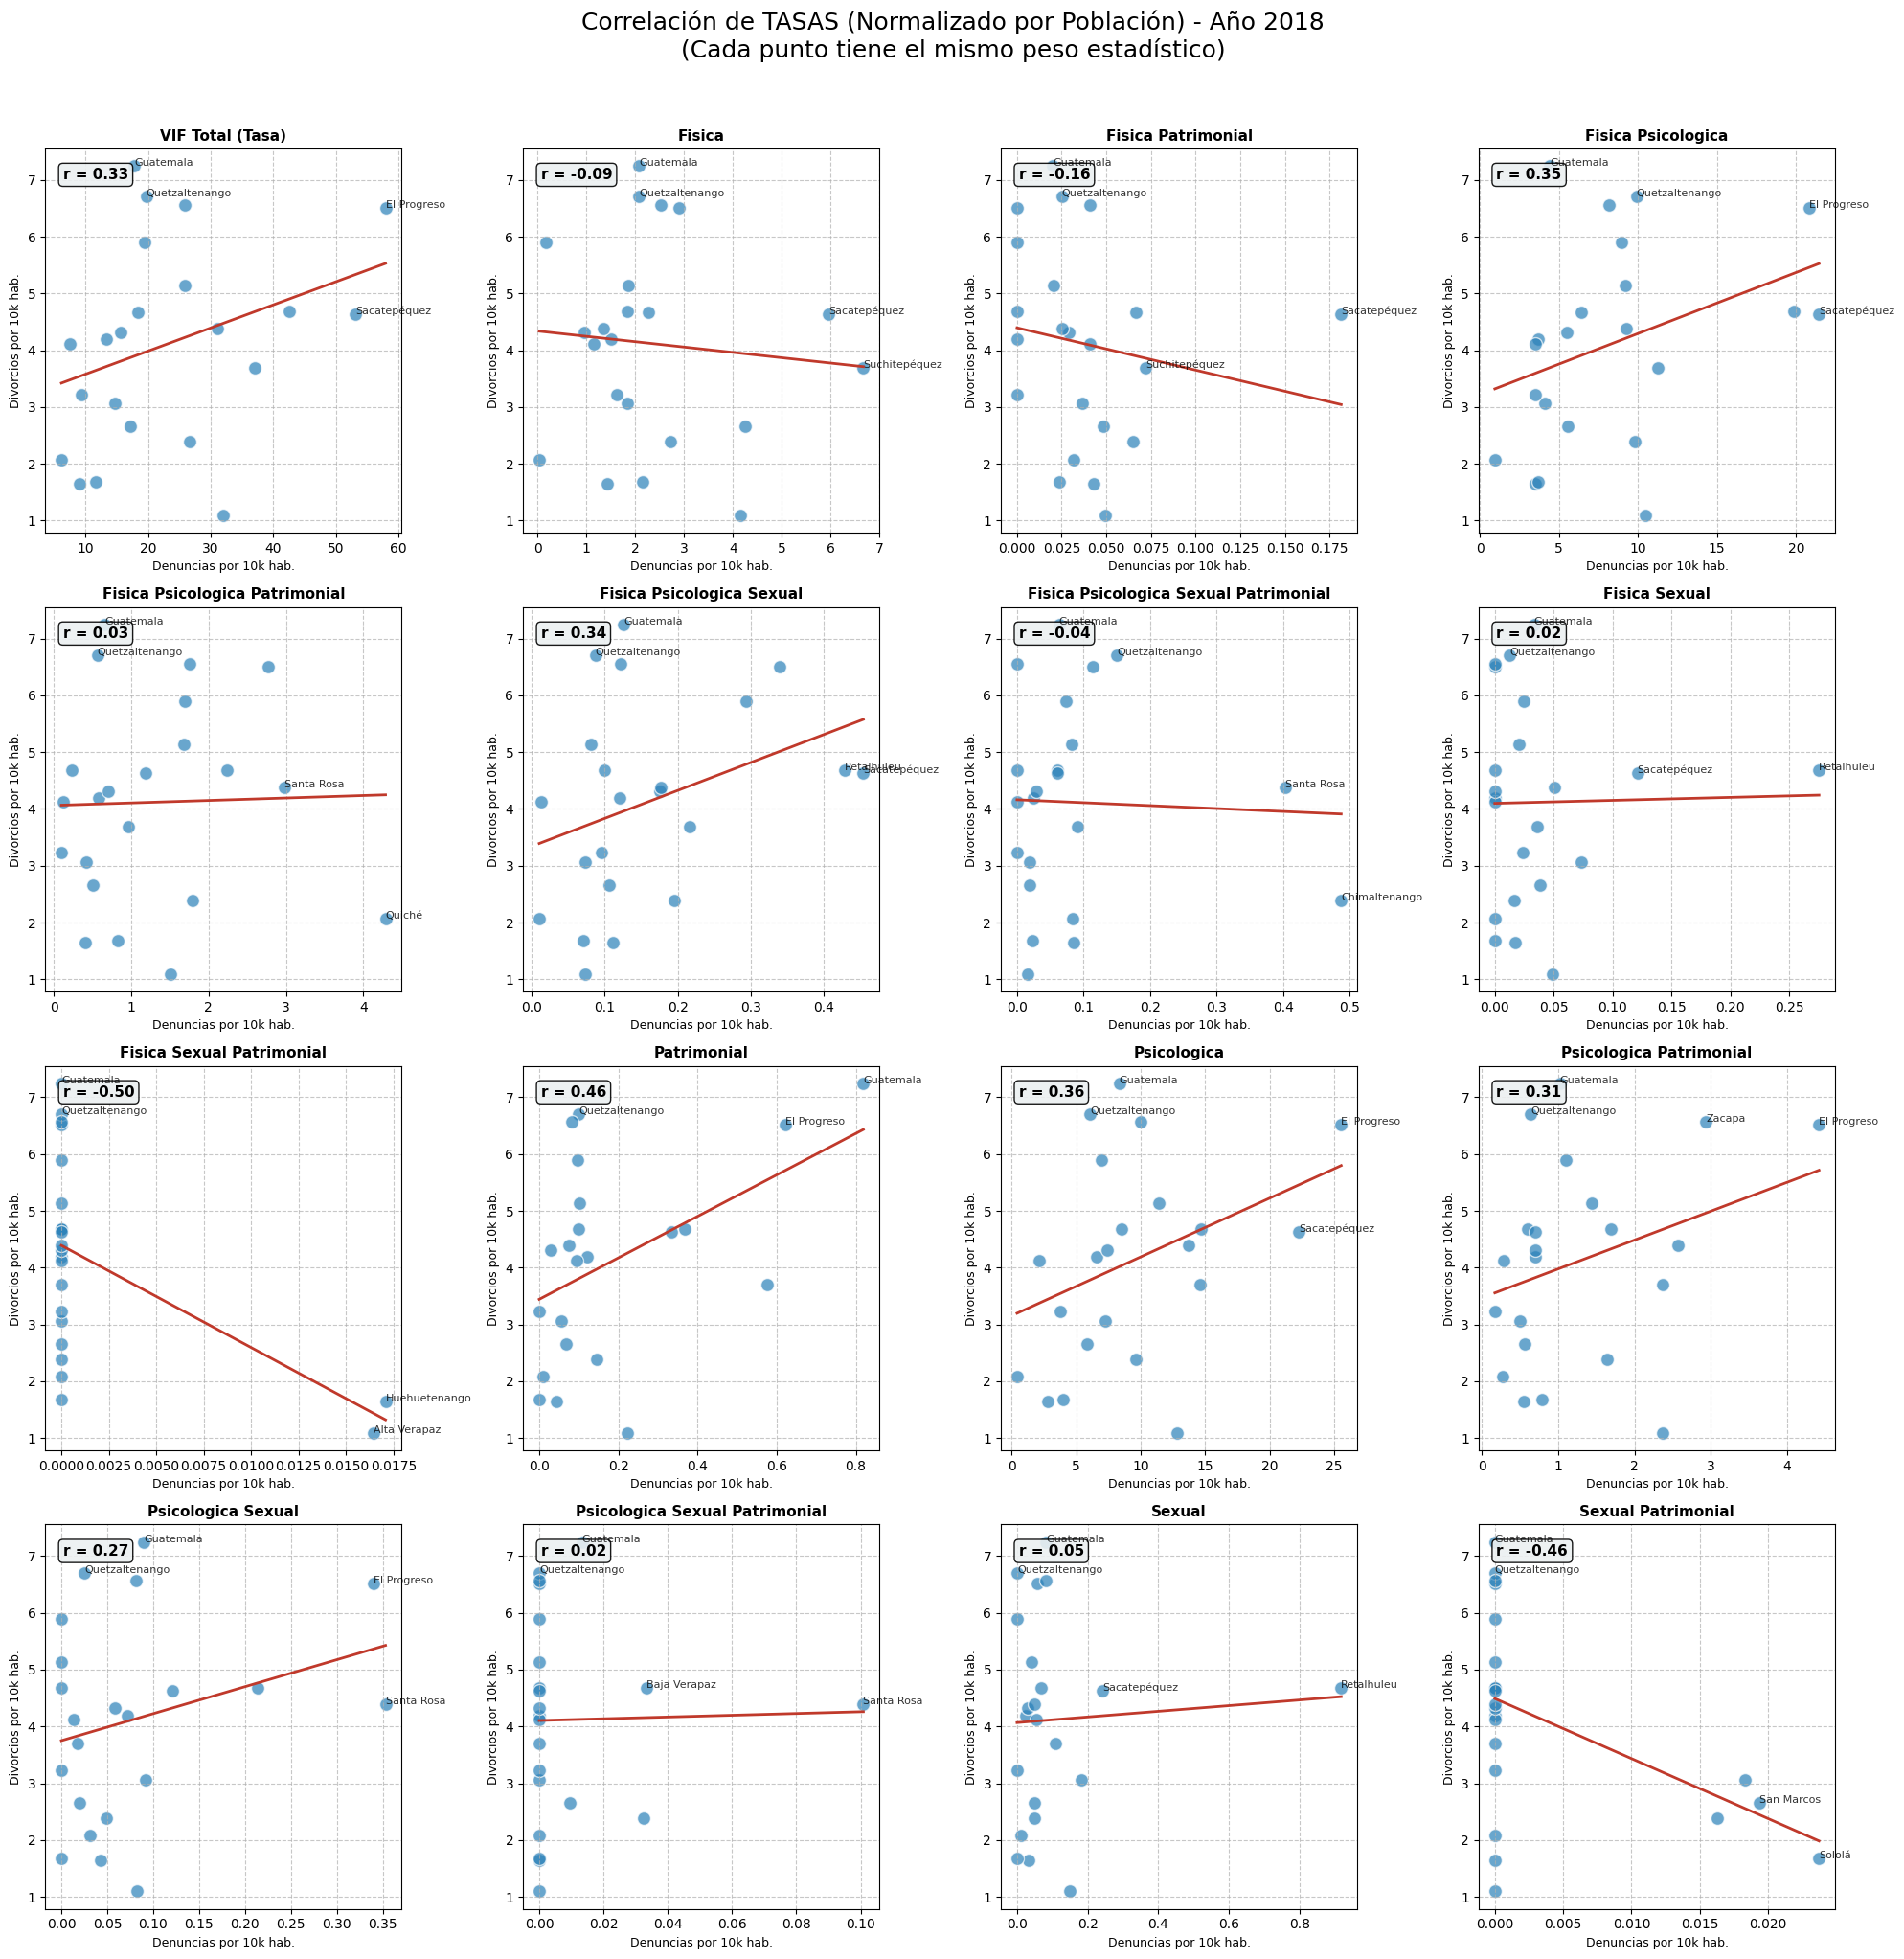

In [2]:
try:
    import data_pipeline as dp
except ImportError:
    PROJECT_ROOT = Path.cwd().parent
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))
    import data_pipeline as dp

def generar_dispersion_tasas_2018():
    # 1. Cargar datos del panel completo
    print("Cargando datos del panel...")
    df = dp.build_panel()

    # 2. Filtrar SOLO 2018
    df_2018 = df[df['anio'] == 2018].copy()
    
    if df_2018.empty:
        print("Error: No se encontraron datos para el año 2018.")
        return

    # 3. Cargar población para normalizar
    project_root = Path.cwd().parent if Path.cwd().name == 'Visualizaciones_Exploratorias' else Path.cwd()
    pob_path = project_root / 'Datos' / 'Poblacion' / 'poblacion_total.csv'
    
    if not pob_path.exists():
        # Intento alternativo
        pob_path = Path('../Datos/Poblacion/poblacion_total.csv')
        if not pob_path.exists():
            print("Error: No se encontró el archivo de población para normalizar.")
            return
        
    df_pob = pd.read_csv(pob_path)
    df_pob = df_pob.rename(columns={'Departamento': 'departamento', 'Población total censada': 'poblacion'})
    df_pob['departamento'] = df_pob['departamento'].str.strip()
    
    # 4. Fusionar datos
    df_plot = df_2018.merge(df_pob[['departamento', 'poblacion']], on='departamento', how='inner')
    
    # 5. Calcular Tasas por cada 10,000 habitantes (para números leibles)
    # Lista de tipos de VIF
    tipos_vif = [
        'vif_total',
        'vif_tipo_fisica',
        'vif_tipo_fisica_patrimonial',
        'vif_tipo_fisica_psicologica',
        'vif_tipo_fisica_psicologica_patrimonial',
        'vif_tipo_fisica_psicologica_sexual',
        'vif_tipo_fisica_psicologica_sexual_patrimonial',
        'vif_tipo_fisica_sexual',
        'vif_tipo_fisica_sexual_patrimonial',
        'vif_tipo_patrimonial',
        'vif_tipo_psicologica',
        'vif_tipo_psicologica_patrimonial',
        'vif_tipo_psicologica_sexual',
        'vif_tipo_psicologica_sexual_patrimonial',
        'vif_tipo_sexual',
        'vif_tipo_sexual_patrimonial'
    ]
    # Filtrar columnas existentes
    tipos_vif = [col for col in tipos_vif if col in df_plot.columns]

    # Calcular tasa de divorcios
    df_plot['tasa_divorcios'] = (df_plot['divorcios_total'] / df_plot['poblacion']) * 10000

    # Calcular tasas para cada tipo de VIF
    tasas_vif = []
    for tipo in tipos_vif:
        new_col = f'tasa_{tipo}'
        df_plot[new_col] = (df_plot[tipo] / df_plot['poblacion']) * 10000
        tasas_vif.append(new_col)

    # 6. Generar Grid de Gráficos (Subplots)
    num_plots = len(tasas_vif)
    cols = 4
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    # Fondo limpio
    # Outliers para etiquetar (opcional, ajustamos según lo que salga)
    # Al normalizar, los outliers cambian (ya no es Guatemala por tamaño, quizás sea El Progreso o Zacapa por tasa)
    # Etiquetaremos los top 3 de cada gráfico dinámicamente

    for i, tasa_col in enumerate(tasas_vif):
        ax = axes[i]
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Scatter Plot - Todos del mismo tamaño para "mismo peso", o sutilmente variable
        ax.scatter(
            df_plot[tasa_col],
            df_plot['tasa_divorcios'],
            s=100, # Tamaño fijo y visible
            alpha=0.7,
            color='#2980b9', # Azul "Flat UI"
            edgecolors='white'
        )

        # Regresión lineal
        if df_plot[tasa_col].sum() > 0:
             # Drop NaNs for polyfit
            valid_idx = df_plot[tasa_col].notna() & df_plot['tasa_divorcios'].notna()
            x_valid = df_plot.loc[valid_idx, tasa_col]
            y_valid = df_plot.loc[valid_idx, 'tasa_divorcios']
            
            if len(x_valid) > 1:
                m, b = np.polyfit(x_valid, y_valid, 1)
                x_range = np.linspace(x_valid.min(), x_valid.max(), 100)
                y_range = m * x_range + b
                
                ax.plot(
                    x_range,
                    y_range,
                    color='#c0392b',
                    linestyle='-',
                    linewidth=2
                )
                
                # Correlación
                corr = x_valid.corr(y_valid)
                ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', 
                            fontsize=11, fontweight='bold', bbox=dict(boxstyle="round", fc="#ecf0f1", alpha=0.9))

        # Títulos limpios
        clean_title = tasa_col.replace('tasa_vif_tipo_', '').replace('_', ' ').title()
        if 'Total' in clean_title: clean_title = 'VIF Total (Tasa)'
            
        ax.set_title(clean_title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Denuncias por 10k hab.', fontsize=9)
        ax.set_ylabel('Divorcios por 10k hab.', fontsize=9)
        
        # Etiquetar los 3 departamentos más extremos en X o Y para contexto
        # Identificar puntos interesantes
        top_x = df_plot.nlargest(2, tasa_col).index
        top_y = df_plot.nlargest(2, 'tasa_divorcios').index
        indices_to_label = set(top_x).union(set(top_y))
        
        for idx in indices_to_label:
            row = df_plot.loc[idx]
            ax.text(row[tasa_col], row['tasa_divorcios'], row['departamento'], fontsize=8, alpha=0.8)

    # Limpieza final
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Correlación de TASAS (Normalizado por Población) - Año 2018\n(Cada punto tiene el mismo peso estadístico)', fontsize=18, y=1.02)
    plt.tight_layout()
    
    output_path = 'dispersion_tasas_2018_normalizado.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico de tasas generado: {output_path}")

generar_dispersion_tasas_2018()